В цьому домашньому завданні ми з вами побудуємо повноцінне ML-рішення реальної ML-задачі. Ви вже маєте всі знання, які для цього потрібні. Дотримуйтесь інструкцій, та користуйтесь матеріалами лекцій, аби виконувати завдання. Тут інструкції будуть детальні, а в подільших завданнях - будуть ставати все менш детальними, аби ви вже починали самостійно структурувати ML-проєкт і до кінця курсу для вас розвʼязати будь-яку ML–задачу було eazy-breezy.

## Dataset

Будемо працювати з набором даних `cars.csv`, який описує автомобілі і їх ціну у індійських рупіях :) Мета - передбачити ціну авто за його характеристиками. Опис набору даних:

| Назва рядка            | Опис                                                                                                                                                 |
|------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------|
| Car_ID                 | Унікальний ідентифікатор для кожного оголошення про автомобіль.                                                                                         |
| Brand                  | Бренд або виробник автомобіля (наприклад, Toyota, Honda, Ford тощо).                                                                                     |
| Model                  | Модель автомобіля (наприклад, Camry, Civic, Mustang тощо).                                                                                               |
| Year                   | Рік виготовлення автомобіля.                                                                                                                            |
| Kilometers_Driven      | Загальний пробіг автомобіля у кілометрах.                                                                                                               |
| Fuel_Type              | Тип палива, який використовує автомобіль (наприклад, бензин, дизель, електро тощо).                                                                      |
| Transmission           | Тип трансмісії автомобіля (наприклад, механічна, автоматична).                                                                                           |
| Owner_Type             | Кількість попередніх власників автомобіля (наприклад, перший, другий, третій).                                                                           |
| Mileage                | Паливна ефективність автомобіля у кілометрах на літр.                                                                                                   |
| Engine                 | Об'єм двигуна автомобіля в кубічних сантиметрах (CC).                                                                                                   |
| Power                  | Максимальна потужність автомобіля в кінських силах (bhp).                                                                                               |
| Seats                  | Кількість місць в автомобілі.                                                                                                                           |
| Price                  | Вартість автомобіля в INR (індійські рупії), що є цільовою змінною для прогнозування.                                                                   |

# Імпорти

Для зручності рекомендую всі імпорти розмістити тут нагорі, аби коли ви перезавантажували ноутбук, одразу можна було в один запуск клітинки імпортувати всі потрібні бібліотеки.

In [149]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split


# Знайомство з даними

**Завдання 1.** Завантажте набір даних `cars.csv` в pandas.DataFrame. Виведіть перші 5 записів.

In [150]:
cars_df = pd.read_csv('cars.csv')

In [151]:
cars_df.head()

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1,Toyota,Corolla,2018,50000,Petrol,Manual,First,15,1498,108,5,800000
1,2,Honda,Civic,2019,40000,Petrol,Automatic,Second,17,1597,140,5,1000000
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4,2500000
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5,600000
4,5,Hyundai,Sonata,2016,60000,Diesel,Automatic,Second,18,1999,194,5,850000


**Завдання 2.** Виведіть типи даних колонок даних, а також дослідіть, які по факту типи даних мають записи в кожній колонці (тип `object` може містити різні типи даних) і скільки значень є в кожній категоріальній колонці.

Напишіть висновок, скільки в наборі даних числових та категоріальних колонок кожного з трьох різних типів (бінарна, мільтикатегоріальна без порядку, мультикатегоріальна з порядком). Шаблон висновку

```
В наборі даних 10 числових і 10 категоріальних колонок з них
- 2 бінарні (мають лише 2 значення)
- 6 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку
- 2 колонки, в яких можна встановити відношення порядку (наприклад Small<Medium<Large)
```

Якщо не знаєте, як це зробити з `pandas` - ось підказка, які методи можуть допомогти вам виконати це завдання

- pandas.DataFrame.info()
- pandas.DataFrame.dtypes
- pandas.DataFrame.loc[...]
- pandas.DataFrame.select_dtypes(...)
- pandas.Series.unique()
- pandas.Series.nunique()

Детальніше ознайомитись з кожним ви можете в [документації](https://pandas.pydata.org/docs/reference/frame.html), або написати в окремій клітинці знак питання і назву методу (тільки приберіть це перед здачею, бо перегляд документації - не допомагає зрозуміти дані і хід думок, а Ваша робота - це як презентація замовнику зробленої задачі).


In [152]:
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Car_ID             100 non-null    int64 
 1   Brand              100 non-null    object
 2   Model              100 non-null    object
 3   Year               100 non-null    int64 
 4   Kilometers_Driven  100 non-null    int64 
 5   Fuel_Type          100 non-null    object
 6   Transmission       100 non-null    object
 7   Owner_Type         100 non-null    object
 8   Mileage            100 non-null    int64 
 9   Engine             100 non-null    int64 
 10  Power              100 non-null    int64 
 11  Seats              100 non-null    int64 
 12  Price              100 non-null    int64 
dtypes: int64(8), object(5)
memory usage: 10.3+ KB


### Спостереження
Всього є 13 колонок. Car_ID - насправді, нічого не адсть нам, її можна або видалити, або не брати до уваги про побудові моделі.

Всього є 100 записів даних. В жодній з колонок немає пропущених значень, що є добре, не потрібно проводити імпутацію, заповнювати пропущені значення.

In [153]:
cars_df.dtypes

,0
Car_ID,int64
Brand,object
Model,object
Year,int64
Kilometers_Driven,int64
Fuel_Type,object
Transmission,object
Owner_Type,object
Mileage,int64
Engine,int64


In [154]:
cars_df.select_dtypes(include='number')

,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Price
0,1,2018,50000,15,1498,108,5,800000
1,2,2019,40000,17,1597,140,5,1000000
2,3,2017,20000,10,4951,395,4,2500000
3,4,2020,30000,23,1248,74,5,600000
4,5,2016,60000,18,1999,194,5,850000
...,...,...,...,...,...,...,...,...
95,96,2019,22000,16,1950,191,5,2900000
96,97,2017,38000,13,2755,171,7,1400000
97,98,2018,26000,18,1497,121,5,750000
98,99,2019,24000,17,1497,113,5,850000


In [155]:
cars_df.select_dtypes(exclude='number')

,Brand,Model,Fuel_Type,Transmission,Owner_Type
0,Toyota,Corolla,Petrol,Manual,First
1,Honda,Civic,Petrol,Automatic,Second
2,Ford,Mustang,Petrol,Automatic,First
3,Maruti,Swift,Diesel,Manual,Third
4,Hyundai,Sonata,Diesel,Automatic,Second
...,...,...,...,...,...
95,Mercedes,C-Class,Diesel,Automatic,First
96,Toyota,Innova Crysta,Diesel,Manual,Second
97,Ford,EcoSport,Petrol,Manual,Third
98,Hyundai,Verna,Petrol,Automatic,Second


In [156]:
# Отримуємо список колонок типу 'object'
object_cols = cars_df.select_dtypes(exclude='number').columns

# Отримуємо словник унікальних значень для кожної колонки
unique_object_values = {col: cars_df[col].unique() for col in object_cols}

# Виводимо унікальні значення для кожної колонки
for col, unique_vals in unique_object_values.items():
    print(f"{cars_df[col].nunique()} унікальних значень в колонці '{col}'. Список унікальних значень: {unique_vals}\n")

11 унікальних значень в колонці 'Brand'. Список унікальних значень: ['Toyota' 'Honda' 'Ford' 'Maruti' 'Hyundai' 'Tata' 'Mahindra' 'Volkswagen'
 'Audi' 'BMW' 'Mercedes']

58 унікальних значень в колонці 'Model'. Список унікальних значень: ['Corolla' 'Civic' 'Mustang' 'Swift' 'Sonata' 'Nexon' 'Scorpio' 'Polo'
 'A4' 'X1' 'C-Class' 'Endeavour' 'Creta' 'Harrier' 'Ertiga' 'City'
 'Tiguan' 'Q3' '5 Series' 'GLC' 'Innova' 'Figo' 'Verna' 'Altroz' 'Thar'
 'Passat' 'A6' 'X3' 'E-Class' 'Fortuner' 'Aspire' 'Elantra' 'Safari'
 'Vitara' 'WR-V' 'Ameo' 'A3' '7 Series' 'GLE' 'Yaris' 'Ranger' 'Santro'
 'Tigor' 'S-Cross' 'BR-V' 'T-Roc' 'Q7' 'X5' 'GLA' 'Camry' 'Venue' 'Tiago'
 'XUV300' 'Vento' 'A5' '3 Series' 'Innova Crysta' 'EcoSport']

2 унікальних значень в колонці 'Fuel_Type'. Список унікальних значень: ['Petrol' 'Diesel']

2 унікальних значень в колонці 'Transmission'. Список унікальних значень: ['Manual' 'Automatic']

3 унікальних значень в колонці 'Owner_Type'. Список унікальних значень: ['First' 'Se

### Спостереження

```
В наборі даних 8 числових і 5 категоріальних колонок з них
- 2 бінарні (мають лише 2 значення): `Fuel_Type`, `Transmission`
- 2 мультикатегоріальні (більше 2х значень) зі значеннями, для яких немає відношення порядку
- 1 колонка, в якій можна встановити відношення порядку: `Owner_Type` ( значення ['First' 'Second' 'Third']).
```

**Завдання 3**. Розділіть дані на тренувальні і тест. Відведіть в тест 20%, поставте `random_state=12`. Ми будемо передбачати колонку `Price` - тож, вона є цільовою змінною. В результаті у Вас має бути 4 набори даних `X_train, X_test, y_train, y_test`.

Надалі ми всюди тренуємо методи для кодування, масштабування та саму модель тільки на тренувальних даних X_train (та y_train для моделі), а на тестувальних лише використовуємо вже навчені методи для кодування, масштабування і модель викликаючи в них `transform()` (для методів обробки даних) або `predict()` (для моделі).

І так само треба робити завжди.

In [157]:
# Create a list of columns to keep
columns_input = [col for col in cars_df.columns if col != 'Price']

# Визначаємо вхідні дані і таргет
inputs, targets = cars_df[columns_input], cars_df['Price']

X_train, X_test, y_train, y_test = train_test_split(inputs, targets, test_size=0.2, random_state=12)

# X_train.head(), X_test.head(), y_train.head(), y_test.head()

**Завдання 4**. Кодуємо категоріальні колонки.

1. Закодуйте колонки з бінарними значеннями `Fuel_Type` і `Transmission` так, аби вони були у чисельному представленні і містили лише 0 так 1. Приклад був у лекції. Значення 1 нехай буде у категорії, яка містить більше значень в колонці.

2. Закодуйте колонку `Brand` з використанням `sklearn.preprocessing.OneHotEncoder` аналогічно до того, як ми робили це в лекції. Увага! Ми робимо виклик методу `Encoder.fit()` на тренувальних даних `X_train`, а на тестувальних тільки викликаємо `Encoder.transform()`. Додайте закодовані значення в набори даних `X_train`, `X_test`.

3. Колонку `Owner_Type` з використанням `sklearn.preprocessing.OrdinalEncoder` я закодую для вас. Проаналізуйте, що відбувається.

Колонка `Model` містять забагато значень для кодування в тому вигляді, як вона є зараз, з огляду на невелику кількість даних. Якщо ви бачите, як можна згрупувати значення в цій колонці скоротивши кількість унікальних значень до 3-5, то можете виконати ще цю трансформацію, використати цю колонку в моделі і отримати додаткову практику і бал, якщо все буде зроблено правильно. А якщо неправильно - то фідбек на Вашу роботу :)

In [158]:
# функція для кодування бінарних значень
def encode_binary(df, column_src):
  column_values = df[column_src].unique()
  # ми отримаємо значення колонок і кількість появ значень в колонці, сортовані від найбльшої кількості до найменшої
  value_counts_series = df[column_src].value_counts(ascending=True)

  if(value_counts_series.size != 2):
    return

  column_codes = {}

  index = 0
  for value, count in value_counts_series.items():
    column_codes[value] = index
    index += 1

  df[f'{column_src}_Code'] = df[column_src].map(column_codes)

  return

In [159]:
encode_binary(X_train, 'Fuel_Type')
encode_binary(X_train, 'Transmission')

encode_binary(X_test, 'Fuel_Type')
encode_binary(X_test, 'Transmission')

In [160]:
from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder()
enc.fit(X_train[['Brand']])

X_train[enc.categories_[0]] = enc.transform(X_train[['Brand']]).toarray()
X_test[enc.categories_[0]] = enc.transform(X_test[['Brand']]).toarray()

In [161]:
from sklearn.preprocessing import OrdinalEncoder

ordenc = OrdinalEncoder(categories=[['First', 'Second', 'Third']]) # визначаємо порядок категорій
ordenc.fit(X_train[['Owner_Type']])

X_train['Owner_Type_Codes'] = ordenc.transform(X_train[['Owner_Type']])
X_test['Owner_Type_Codes'] = ordenc.transform(X_test[['Owner_Type']])

### Спостереження
OrdinalEncoder - зберіг нам послдідовність категорій, тобто в  OneHotEncoder значення б закождувались в порядку їх появи ів датайреймі. Тому якщо ми мали 'Second' дл япершого рядка, 'Third' для другого, і десь потім пізнеіше в датасеті попався 'First' рядок, то овни були б закодовані як  'Second' - 0, 'Third' - 1, 'First' - 2. Тобто якби ми хотіли відсортувати за Owner_Type (спочатку перший власник, потім другий, потім третій), ми могли б використати Owner_Type_Code, але у нас не був збережений порядок. Тому OrdinalEncoder дозволяє зберегти порядок: 'First' - 0, 'Second' - 1, 'Third' - 2.

In [162]:
# Завдання: Колонка Model містять забагато значень для кодування в тому вигляді, як вона є зараз, з огляду на невелику кількість даних.
# Якщо ви бачите, як можна згрупувати значення в цій колонці скоротивши кількість унікальних значень до 3-5, то можете виконати ще цю трансформацію,
# використати цю колонку в моделі і отримати додаткову практику і бал, якщо все буде зроблено правильно. А якщо неправильно - то фідбек на Вашу роботу :)

# Розв"язок/Хід думок. У нас даних мало, всього 100 записів. Якщо подивтись повторення кожного значення 'Model', то буде видно, що є лише 3 моделі, які мають 3 повторення, решта мають 1-2 повторення:
model_value_counts = X_train['Model'].value_counts()
model_value_counts

,count
Model,
Altroz,3
Mustang,3
C-Class,3
T-Roc,2
A5,2
Q7,2
A3,2
XUV300,2
A6,2


In [163]:
# Тому для кодування я б використала наступний прийом:
# 1. Додати нову колонку 'Model_Group' і в неї записати дані настуним алгоритом:
#   - якщо це колонка зі списку всіх колонок, що має 3 повторення в йсьому датасеті (Altroz	- 3, Mustang - 3, C-Class -	3), то записати назву моделі як є
#   - якщо це будь яка інша колонка, то записати значення 'Other'
# 2. Використати 'OneHotEncoder' для нової колонки 'Model_Group'

model_group_keys = model_value_counts[model_value_counts == model_value_counts.max()].keys().values
# display(model_group_keys)

X_train['Model_Group'] = X_train['Model'].where(X_train['Model'].isin(model_group_keys), 'Other')
X_test['Model_Group'] = X_test['Model'].where(X_test['Model'].isin(model_group_keys), 'Other')
# display(X_train['Model_Group'].value_counts())

enc = OneHotEncoder()
enc.fit(X_train[['Model_Group']])

X_train['Model_Group_' + enc.categories_[0]] = enc.transform(X_train[['Model_Group']]).toarray()
X_test['Model_Group_' + enc.categories_[0]] = enc.transform(X_test[['Model_Group']]).toarray()

Очікуваний результат після трансформацій:

In [164]:
pd.set_option('display.max_columns', 100)
display(X_train.head()), display(X_test.head())

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Model_Group,Model_Group_Altroz,Model_Group_C-Class,Model_Group_Mustang,Model_Group_Other
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,Other,0.0,0.0,0.0,1.0
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Other,0.0,0.0,0.0,1.0
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Other,0.0,0.0,0.0,1.0
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,Other,0.0,0.0,0.0,1.0
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,Other,0.0,0.0,0.0,1.0


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Model_Group,Model_Group_Altroz,Model_Group_C-Class,Model_Group_Mustang,Model_Group_Other
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,1,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Other,0.0,0.0,0.0,1.0
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,1,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,Other,0.0,0.0,0.0,1.0
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,Other,0.0,0.0,0.0,1.0
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,1,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Other,0.0,0.0,0.0,1.0
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,1,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,Other,0.0,0.0,0.0,1.0


(None, None)

**Завдання 5.** Оберіть лише числові колонки з `X_train` (можна для цього використати `pandas.select_dtypes(...)` або видалити всі НЕчислові дані, вони нам вже не потрібні), обʼєднайте ці дані з `y_train` (зручно з `pandas.concat([df1, df2], axis=1)`), побудуйте для цих даних матрицю кореляції і проаналізуйте її. Напишіть висновок, які колонки корелюють з цільовою змінною на більш ніж 0.5 за модулем (може бути як позитивна, так і негативна кореляція).

In [165]:
X_train = X_train.select_dtypes(include='number')
X_test = X_test.select_dtypes(include='number')

cars_df_train = pd.concat([X_train, y_train], axis=1)

correlation_matrix = cars_df_train.corr()

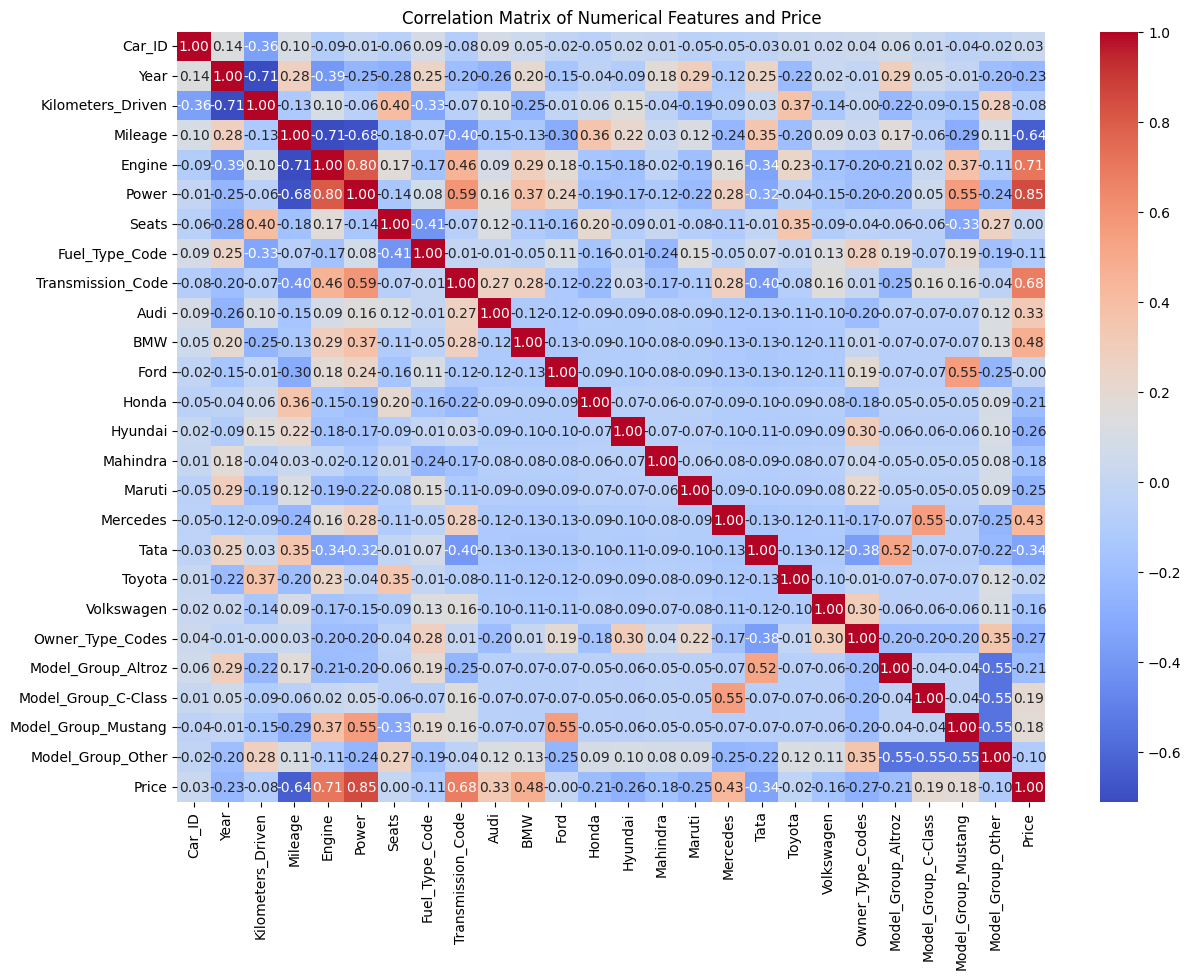

In [166]:

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features and Price')
plt.show()

### Спостереження

Найбільні кореляції маємо:
Power: 0.85 (птужність автомобіля має найбільшу кореляцію)
Engine: 0.71
Transmission_Code: 0.68 (загалом відома інформація, що авто з коробкою автоматом має вищу вартість)
Milleage: -0.64 (причому тут обернена залежність, чим вище пробіг, тим нижча вартість авто)



**Завдання 6**. Тренуємо лінійну регресію.
0. Видаліть усі НЕчислові колонки з `X_train`, `X_test`, якщо ще цього не зробили.
1. Натренуйте лінійну регресую з `sklearn` на усіх числових даних тренувального набору `X_train`.
2. Зробіть передбачення на  `X_train`, `X_test`. Знайдіть і виведіть root mean squared error відхилення передбачення від справжніх значень цільової змінної.
3. Побудуйте графік розсіювання передбачень проти реальних даних цільової змінної для тренувального і тестувального наборів даних. Що можете сказати про якість моделі?

In [167]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Створюємо і одразу тренуємо модель
model_lr = LinearRegression().fit(X_train, y_train)

# Робимо передбачення моделлю
predictions_lr_train = model_lr.predict(X_train)
predictions_lr_test = model_lr.predict(X_test)

# Разуємо лосс
loss_lr_train = np.sqrt(mean_squared_error(y_train, predictions_lr_train, multioutput = 'uniform_average'))
loss_lr_test = np.sqrt(mean_squared_error(y_test, predictions_lr_test, multioutput = 'uniform_average'))
print('rmse для train: ', loss_lr_train)
print('rmse для test: ', loss_lr_test)

# щоб зрозуміти, чи помилка занадто велика, можна для початку глянути ще на середнє відхилення
y_train.describe().map('{:,.2f}'.format)

rmse для train:  198027.17400981067
rmse для test:  331262.4896930148


,Price
count,80.00
mean,"1,680,000.00"
std,"1,040,405.23"
min,"450,000.00"
25%,"700,000.00"
50%,"1,500,000.00"
75%,"2,700,000.00"
max,"4,000,000.00"


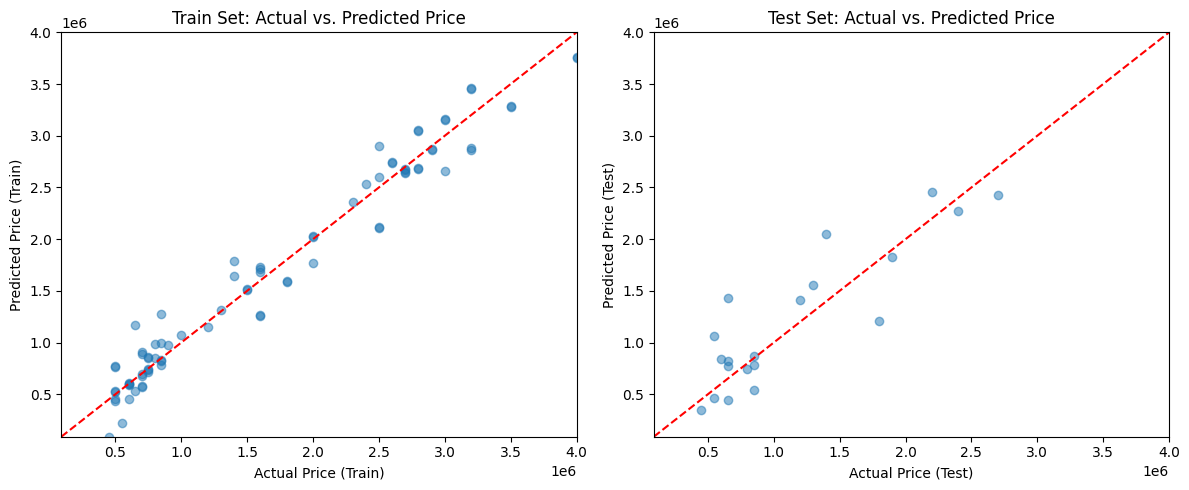

In [168]:
plt.figure(figsize=(12, 5))

# Determine common min and max for scaling
all_prices = np.concatenate([y_train, y_test, predictions_lr_train, predictions_lr_test])
min_price = all_prices.min()
max_price = all_prices.max()

plt.subplot(1, 2, 1)
plt.scatter(y_train, predictions_lr_train, alpha=0.5)
plt.plot([min_price, max_price], [min_price, max_price], 'r--')
plt.xlabel('Actual Price (Train)')
plt.ylabel('Predicted Price (Train)')
plt.title('Train Set: Actual vs. Predicted Price')
plt.xlim(min_price, max_price)
plt.ylim(min_price, max_price)

plt.subplot(1, 2, 2)
plt.scatter(y_test, predictions_lr_test, alpha=0.5)
plt.plot([min_price, max_price], [min_price, max_price], 'r--')
plt.xlabel('Actual Price (Test)')
plt.ylabel('Predicted Price (Test)')
plt.title('Test Set: Actual vs. Predicted Price')
plt.xlim(min_price, max_price)
plt.ylim(min_price, max_price)

plt.tight_layout()
plt.show()

### Спостереження

На натренованій моделі помилка передбачення десь 20% від стандартного відхилення, що дуже добре. Для тестового набору даних вона дещо вища, що логічно, але все одно приблизно 30% від стандартного відхилення, що вже є добре.
Тепер глянувши на графік моделі можна побачити, що вона натренована добре.

Графіки розсіювання показують, що модель натренована добре. Думаю, що можна ще трошки покращити значення, і ще бачимо, що в нашу вибірку y_test не попало значень вищих цін за авто. Але загалом мені здається, що модель справляється непогано.


**Завдання 7**. Ми хочемо проаналізувати як впливає кожен чинник на цілову змінну. Для цього давайте промасштабуємо наші дані.
1. Зробіть масштабування незалежних змінних використовуючи `StandardScaler`. Тренуємо на тренувальних даних, а на тестувальних лише викликаємо `transform`.

2. Натренуйте модель на відмасштабованих даних і перегляньте коефіцієнти моделі. Які колонки є найвпливовішими на формування передбачення з точки зору коефіцієнтів? Проаналізуйте напрям дії найважливіших коефіцієнтів. Чи це логічно з точки зору значення відповідних змінних, що вони впливають на цільову змінну саме в напрямі збільшення / зменшення?

In [169]:
from sklearn.preprocessing import StandardScaler

ss_scaler = StandardScaler().set_output(transform="pandas")
ss_scaler.fit(X_train)

# Масштабуємо
X_train_scaled = ss_scaler.transform(X_train)
X_test_scaled = ss_scaler.transform(X_test)

# display(X_train_scaled)

# Тренуємо модель
model_lr_scaled = LinearRegression().fit(X_train_scaled, y_train)

weights_df_lr_scaled = pd.DataFrame({
    'feature': np.append(X_train.columns, 1),
    'weight': np.append(model_lr_scaled.coef_, model_lr_scaled.intercept_),
    'weight_unsigned': np.abs(np.append(model_lr_scaled.coef_, model_lr_scaled.intercept_))
})
weights_df_lr_scaled.sort_values('weight_unsigned', ascending=False)

,feature,weight,weight_unsigned
25,1,1.680000e+06,1.680000e+06
5,Power,6.386834e+05,6.386834e+05
7,Fuel_Type_Code,-1.840299e+05,1.840299e+05
9,Audi,1.789214e+05,1.789214e+05
10,BMW,1.524704e+05,1.524704e+05
16,Mercedes,1.502545e+05,1.502545e+05
13,Hyundai,-1.313254e+05,1.313254e+05
14,Mahindra,-1.313040e+05,1.313040e+05
23,Model_Group_Mustang,-1.263662e+05,1.263662e+05
2,Kilometers_Driven,-1.226889e+05,1.226889e+05


### Спостереження

Найвпливовіші колонки з точки зору коефіцієнтів є:
- **Power**. Для мене логічно, що потужність матиме вплив.
- **Fuel_Type_Code**. Це цікаво, тому що тут є обернений вплив: тип Disel/Дизель має код 0 і має вищу вартість, Petrol/Бензин має код 1 і матиме меншу вартість? Неочікувано, але я погуглила і так і є
  "Petrol cars are generally cheaper to purchase upfront, often costing 10–15% less than equivalent diesel models."     
- Далі неочікувано йдуть марки автомобілів:
  - **Audi**
  - **BMW**
  - **Mercedes**
  Хоча загалом логічно, тому що це дорожчі марки автомобілів.

Також з цікавого:
- **Model_Group_Mustang**. А це якраз виділена група автомобілів з завдання 4. Дуже класно, що вдалось цей вплив побачити тут.
- **Kilometers_Driven** - знову обенений звязок. Що теж логічно, чим більше авто проїхало, тим зменшуватиметься вартість автомобіля.
- **Transmission_Code** - коробка передач також впливає на ціну (теж відомий факт)

**Завдання 8.** На тих самих відмасштабованих даних натренуйте модель з `statsmodels`. Виведіть звіт і проаналізуйте p-value коефіцієнтів. Які ознаки є стат значущими на рівні значущості 0.05? Напишіть їх список.

In [170]:
Y = y_train
X = X_train_scaled
X = sm.add_constant(X)
model_sm = sm.OLS(Y,X)
results_sm = model_sm.fit()


params_df_sm_scaled = pd.DataFrame({
    'param': results_sm.params,
    'param_unsigned': np.abs(results_sm.params)
})
params_df_sm_scaled.sort_values('param_unsigned', ascending=False)

### Параметри ті самі, що й і sklearn

,param,param_unsigned
const,1.680000e+06,1.680000e+06
Power,6.386834e+05,6.386834e+05
Fuel_Type_Code,-1.840299e+05,1.840299e+05
Audi,1.789214e+05,1.789214e+05
BMW,1.524704e+05,1.524704e+05
Mercedes,1.502545e+05,1.502545e+05
Hyundai,-1.313254e+05,1.313254e+05
Mahindra,-1.313040e+05,1.313040e+05
Model_Group_Mustang,-1.263662e+05,1.263662e+05
Kilometers_Driven,-1.226889e+05,1.226889e+05


In [171]:
print(results_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.963
Model:                            OLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                     63.93
Date:                Thu, 12 Feb 2026   Prob (F-statistic):           3.93e-32
Time:                        14:58:59   Log-Likelihood:                -1089.2
No. Observations:                  80   AIC:                             2226.
Df Residuals:                      56   BIC:                             2284.
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                 1.68e+06   2

### Спостереження

- F-statistic:                     63.93
- Prob (F-statistic):           3.93e-32

Високе значення F-статистики та мале p-значення: означає, що модель є значущою і незалежні змінні суттєво покращують пояснення залежної змінної.


Зі звіту бачимо ознаки, які є стат значущими на рівні значущості 0.05:
 - Mileage (p_value=0.046)
 - Power (p_value=0.000)
 - Fuel_Type_Code (p_value=0.000)
 - Transmission_Code (p_value=0.006)
 - Audi (p_value=0.000)
 - BMW (p_value=0.000)
 - Hyundai (p_value=0.000)
 - Mahindra (p_value=0.000)
 - Maruti (p_value=0.002)
 - Mercedes (p_value=0.001)
 - Volkswagen (p_value=0.008)
 - Model_Group_Mustang (p_value=0.011)

**Завдання 9**. Натренуйте лінійну регресію з `statsmodels` тільки на ознаках, які виявлись стат. значущими в попередньому завданні. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared?

In [172]:
Y = y_train
X = X_train_scaled[['Mileage', 'Power', 'Fuel_Type_Code', 'Transmission_Code', 'Audi', 'BMW', 'Hyundai', 'Mahindra', 'Maruti', 'Mercedes', 'Volkswagen', 'Model_Group_Mustang']]
X = sm.add_constant(X)
model_sm = sm.OLS(Y,X)
results_sm = model_sm.fit()

print(results_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.954
Model:                            OLS   Adj. R-squared:                  0.946
Method:                 Least Squares   F-statistic:                     116.3
Date:                Thu, 12 Feb 2026   Prob (F-statistic):           5.88e-40
Time:                        14:58:59   Log-Likelihood:                -1098.1
No. Observations:                  80   AIC:                             2222.
Df Residuals:                      67   BIC:                             2253.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                 1.68e+06    

### Сопстереження

Чи значно змінились R2 і Adj. R-squared?
Для попередньої моделі:
- R-squared:                       0.963
- Adj. R-squared:                  0.948

Для моделі лише зі стат значущими показниками:
- R-squared:                       0.954
- Adj. R-squared:                  0.946

Тобто практично не змінились (навіть стали трооооошки менші). Але мене зацікавили також показники AIC & BIC:
Для попередньої моделі:
- AIC:                             2226.
- BIC:                             2284.

Для моделі лише зі стат значущими показниками:
- AIC:                             2222.
- BIC:                             2253.

Сзожде модель трошки таки покращилась, бо значення цих показників трошки зменшились.

**Завдання 10**. Натренуйте лінійну регресію з `statsmodels` на усіх ознаках з масштабованого `X_train`, у яких p_value в завданні 8 менше за `0.25`. Ми таким чином помʼякшили критерій відбору ознак. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared порівняно з завданням 8? Яку модель з останніх 3х завдань ви б лишили для використання?

In [173]:
Y = y_train
X = X_train_scaled[['Mileage', 'Power', 'Fuel_Type_Code', 'Transmission_Code', 'Audi', 'BMW', 'Hyundai', 'Mahindra', 'Maruti', 'Mercedes', 'Volkswagen', 'Model_Group_Mustang',
                    'Kilometers_Driven', 'Ford', 'Honda', 'Tata', 'Model_Group_C-Class', 'Model_Group_Other']]
X = sm.add_constant(X)
model_sm = sm.OLS(Y,X)
results_sm = model_sm.fit()

print(results_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.963
Model:                            OLS   Adj. R-squared:                  0.952
Method:                 Least Squares   F-statistic:                     87.71
Date:                Thu, 12 Feb 2026   Prob (F-statistic):           1.03e-36
Time:                        14:58:59   Log-Likelihood:                -1089.8
No. Observations:                  80   AIC:                             2218.
Df Residuals:                      61   BIC:                             2263.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                 1.68e+06   2

### Спостереження

Для моделі з усіма озаками:
- R-squared:                       0.963
- Adj. R-squared:                  0.948

Для моделі лише зі стат значущими показниками (p_value > 0.05):
- R-squared:                       0.954
- Adj. R-squared:                  0.946

Для моделі лише з показниками (p_value > 0.25):
- R-squared:                       0.963
- Adj. R-squared:                  0.952

Насправді, всі показники дуже близькі. І кожна з моделей змогла б описати >95% всіх варіацій у залежній змінній (це прямо чудовий результат). Але якщо вже обирати, то напевно остання мождель найкраща. Я до того ж ще глянула на коефіцієнт покращення моделі AIC, то я б використовувала останню модель з p_value > 0.25.